<a href="https://colab.research.google.com/github/LuciousNg/LuciousNg/blob/main/notebooks/03_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 03 — Modeling Baseline

**Team Redefinity — HBAAC 2026 Round 2**  
**Owner:** Bình — Tech Lead  
**Goal Day 2:** train naive baseline + LightGBM baseline, compute local WRMSSE, save model + artifacts.

## 1️⃣ Setup + Paths

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import gc
import json
import joblib
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DRIVE_PATH = '/content/drive/MyDrive/HBAAC_Redefinity_2026'
DATA_PROCESSED = f'{DRIVE_PATH}/01_Data/processed'
MODELS_PATH = f'{DRIVE_PATH}/02_Models'
SUBMISSIONS_PATH = f'{DRIVE_PATH}/03_Submissions'
FIGURES_PATH = f'{DRIVE_PATH}/03_Reports/Figures'

for p in [MODELS_PATH, SUBMISSIONS_PATH, FIGURES_PATH]:
    os.makedirs(p, exist_ok=True)

RANDOM_STATE = 42
print('Setup done')
print('DATA_PROCESSED:', DATA_PROCESSED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done
DATA_PROCESSED: /content/drive/MyDrive/HBAAC_Redefinity_2026/01_Data/processed


## 2️⃣ Load `features_v1.parquet`

File 02 đã save parquet để tránh CSV quá nặng. Ở file 03 mình đọc parquet và chỉ giữ data đủ gần để train baseline cho nhẹ RAM.

In [8]:
# Load features từ file 02
feature_path = f'{DATA_PROCESSED}/features_v1.parquet'

if not os.path.exists(feature_path):
    raise FileNotFoundError(
        f'Không thấy {feature_path}. Check lại file 02 đã save parquet chưa.'
    )

# Đọc parquet
# Nếu RAM yếu, vẫn đọc full trước rồi filter ngay sau đó.
df = pd.read_parquet(feature_path)
df['Date'] = pd.to_datetime(df['Date'])

print('Loaded features')
print('Shape:', df.shape)
print('Date range:', df['Date'].min(), '->', df['Date'].max())
print('Unique SKUs:', df['ItemCode'].nunique())
print('Memory MB:', round(df.memory_usage(deep=True).sum() / 1e6, 1))

Loaded features
Shape: (12745656, 58)
Date range: 2023-07-01 00:00:00 -> 2025-09-05 00:00:00
Unique SKUs: 15972
Memory MB: 3826.9


## 3️⃣ Light RAM Filter

Baseline không cần train từ 2023 ngay. Dùng data từ 2024 để giảm RAM nhưng vẫn đủ seasonality gần đây. Nếu Colab vẫn yếu, đổi `TRAIN_MIN_DATE` thành `2025-01-01`.

In [3]:
# Giảm RAM cho baseline Day 2
TRAIN_MIN_DATE = pd.Timestamp('2024-01-01')

print('Before filter:', df.shape)
df = df.loc[df['Date'] >= TRAIN_MIN_DATE].reset_index(drop=True)
gc.collect()

print('After filter:', df.shape)
print('Date range:', df['Date'].min(), '->', df['Date'].max())
print('Memory MB:', round(df.memory_usage(deep=True).sum() / 1e6, 1))

Before filter: (12745656, 58)
After filter: (9806808, 58)
Date range: 2024-01-01 00:00:00 -> 2025-09-05 00:00:00
Memory MB: 2945.1


## 4️⃣ Time-Based Split

In [4]:
# Split đúng theo phân công
TRAIN_END = pd.Timestamp('2025-08-08')
VAL_START = pd.Timestamp('2025-08-09')
VAL_END = pd.Timestamp('2025-09-05')

train_mask = df['Date'] <= TRAIN_END
val_mask = (df['Date'] >= VAL_START) & (df['Date'] <= VAL_END)

print('Train rows:', train_mask.sum())
print('Val rows:', val_mask.sum())
print('Train date:', df.loc[train_mask, 'Date'].min(), '->', df.loc[train_mask, 'Date'].max())
print('Val date:', df.loc[val_mask, 'Date'].min(), '->', df.loc[val_mask, 'Date'].max())

# Validation phải là 28 ngày x 15,972 SKU nếu file 02 tạo full grid đúng
print('Val unique days:', df.loc[val_mask, 'Date'].nunique())
print('Val unique SKUs:', df.loc[val_mask, 'ItemCode'].nunique())

Train rows: 9359592
Val rows: 447216
Train date: 2024-01-01 00:00:00 -> 2025-08-08 00:00:00
Val date: 2025-08-09 00:00:00 -> 2025-09-05 00:00:00
Val unique days: 28
Val unique SKUs: 15972


## 5️⃣ Chọn Feature Columns

Drop các cột có nguy cơ leakage/same-day info như `sales_amt`, `cost_amt`, `n_transactions`. Profit chỉ dùng để tính WRMSSE weight, không đưa vào model baseline để local CV sạch hơn.

In [9]:
TARGET = 'net_qty'

leakage_or_unused_cols = [
    'Date', 'ItemCode', TARGET,
    # same-day raw info, không dùng cho model
    'sales_amt', 'cost_amt', 'n_transactions',
    'avg_unit_price', 'gross_margin',
    'holiday_name',
    # weight dùng cho metric, không dùng làm feature baseline
    'profit_raw', 'profit_weight', 'weight_share'
]

FEATURES = [c for c in df.columns if c not in leakage_or_unused_cols]

# Chỉ giữ numeric features cho LightGBM
numeric_features = []
for c in FEATURES:
    if pd.api.types.is_numeric_dtype(df[c]):
        numeric_features.append(c)
    else:
        print('Drop non-numeric feature:', c, df[c].dtype)

FEATURES = numeric_features

print(f'Number of model features: {len(FEATURES)}')
print(FEATURES)

Number of model features: 48
['year', 'month', 'day', 'day_of_week', 'week_of_year', 'is_weekend', 'is_month_end', 'is_month_start', 'quarter', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'lag_28', 'lag_35', 'lag_42', 'lag_49', 'lag_56', 'rolling_mean_7', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_max_14', 'rolling_min_14', 'rolling_mean_28', 'rolling_std_28', 'rolling_max_28', 'rolling_min_28', 'days_off', 'is_tet', 'is_after_tet', 'is_national_holiday', 'days_to_tet', 'days_from_tet', 'price_lag_28', 'price_rolling_mean_28', 'price_relative', 'price_lag_35', 'price_change_1week', 'sku_mean_qty', 'sku_std_qty', 'sku_zero_pct', 'sku_total_qty', 'sku_days_active', 'active_day_pct', 'sku_encoded']


## 6️⃣ Build Train / Val Matrix

In [6]:
# Không copy cả df lớn quá nhiều, chỉ lấy cột cần thiết
model_cols = ['Date', 'ItemCode', TARGET] + FEATURES

train_df = df.loc[train_mask, model_cols].reset_index(drop=True)
val_df = df.loc[val_mask, model_cols].reset_index(drop=True)

del train_mask, val_mask
gc.collect()

# Fill NaN còn sót trong feature
for c in FEATURES:
    if train_df[c].isna().any():
        train_df[c] = train_df[c].fillna(0)
    if val_df[c].isna().any():
        val_df[c] = val_df[c].fillna(0)

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_val = val_df[FEATURES]
y_val = val_df[TARGET]

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('y_train min/max:', y_train.min(), y_train.max())
print('y_val min/max:', y_val.min(), y_val.max())
print('Memory train MB:', round(train_df.memory_usage(deep=True).sum() / 1e6, 1))

X_train: (9359592, 48)
X_val: (447216, 48)
y_train min/max: 0.0 10358.0
y_val min/max: 0.0 1002.0
Memory train MB: 2049.8


## 7️⃣ WRMSSE Function

Ưu tiên dùng `utils.py` của Linh nếu có. Nếu chưa có thì dùng fallback local để Bình vẫn train được baseline ngay.

In [10]:
# Try import utils.py của Linh nếu đã có
UTILS_PATH = DATA_PROCESSED
if UTILS_PATH not in sys.path:
    sys.path.append(UTILS_PATH)

USE_LINH_UTILS = False
try:
    from utils import compute_wrmsse as linh_compute_wrmsse
    USE_LINH_UTILS = True
    print('Imported compute_wrmsse từ utils.py của Linh')
except Exception as e:
    print('Chưa import được utils.py của Linh, dùng fallback local.')
    print('Reason:', e)

# Load profit weight từ EDA
sku_profit_path = f'{DATA_PROCESSED}/sku_profit.csv'
if not os.path.exists(sku_profit_path):
    raise FileNotFoundError('Không thấy sku_profit.csv. Cần chạy lại file 01 EDA.')

sku_profit = pd.read_csv(sku_profit_path)
sku_profit['profit_weight'] = sku_profit['profit_weight'].clip(lower=0)

print('sku_profit:', sku_profit.shape)
display(sku_profit.head())

Chưa import được utils.py của Linh, dùng fallback local.
Reason: cannot import name 'compute_wrmsse' from 'utils' (/content/drive/MyDrive/HBAAC_Redefinity_2026/01_Data/processed/utils.py)
sku_profit: (15972, 10)


,ItemCode,profit_raw,total_quantity,total_sales,total_cost,n_transactions,first_date,last_date,profit_weight,weight_share
0,SKU-00001,3.608433e+07,30,36084333,0.0,30,2025-05-26,2025-08-28,3.608433e+07,0.000210
1,SKU-00002,8.012686e+09,5894,8012686409,0.0,5896,2022-01-10,2025-09-05,8.012686e+09,0.046532
2,SKU-00003,1.670068e+10,10935,16700681088,0.0,10936,2022-01-03,2025-09-04,1.670068e+10,0.096986
3,SKU-00004,8.359968e+08,659,835996756,0.0,659,2023-07-19,2024-12-20,8.359968e+08,0.004855
4,SKU-00005,2.243340e+09,1101,2243340437,0.0,1103,2022-01-03,2023-06-26,2.243340e+09,0.013028


In [11]:
def compute_wrmsse_local(train_df, val_df, y_pred, sku_profit,
                         group_col='ItemCode', target_col='net_qty'):
    """
    WRMSSE local cho validation 28 ngày.
    - scale: naive 1-step MSE trên train
    - weight: profit_weight từ EDA, profit âm -> 0
    """
    # Scale denominator theo từng SKU
    tmp_train = train_df[[group_col, 'Date', target_col]].sort_values([group_col, 'Date']).copy()
    tmp_train['diff'] = tmp_train.groupby(group_col)[target_col].diff()
    tmp_train['diff2'] = tmp_train['diff'] ** 2
    scale = tmp_train.groupby(group_col)['diff2'].mean().reset_index(name='scale')

    # Error validation theo từng SKU
    tmp_val = val_df[[group_col, 'Date', target_col]].copy()
    tmp_val['pred'] = y_pred
    tmp_val['err2'] = (tmp_val[target_col] - tmp_val['pred']) ** 2
    mse = tmp_val.groupby(group_col)['err2'].mean().reset_index(name='mse')

    # Merge scale + weight
    score_df = mse.merge(scale, on=group_col, how='left')
    score_df = score_df.merge(
        sku_profit[[group_col, 'profit_weight']],
        on=group_col,
        how='left'
    )

    score_df['profit_weight'] = score_df['profit_weight'].fillna(0).clip(lower=0)

    # Tránh chia 0 cho SKU constant
    score_df = score_df[(score_df['scale'] > 1e-9) & (score_df['profit_weight'] > 0)].copy()

    score_df['rmsse'] = np.sqrt(score_df['mse'] / score_df['scale'])
    score_df['weight_norm'] = score_df['profit_weight'] / score_df['profit_weight'].sum()

    wrmsse = float((score_df['rmsse'] * score_df['weight_norm']).sum())
    return wrmsse, score_df

print('WRMSSE fallback ready')

WRMSSE fallback ready


## 8️⃣ Naive Baseline

In [12]:
# Naive baseline theo plan: dùng lag_28
if 'lag_28' not in val_df.columns:
    raise ValueError('Không thấy lag_28 trong features. Check lại file 02.')

y_pred_naive = val_df['lag_28'].fillna(0).clip(lower=0).astype('float32').values

wrmsse_naive, naive_detail = compute_wrmsse_local(train_df, val_df, y_pred_naive, sku_profit)

print('Naive baseline done')
print(f'Naive WRMSSE: {wrmsse_naive:.6f}')
print('Pred mean/max:', y_pred_naive.mean(), y_pred_naive.max())

Naive baseline done
Naive WRMSSE: 0.672112
Pred mean/max: 0.084847145 600.0


## 9️⃣ LightGBM Baseline

In [13]:
# LightGBM default-ish baseline theo plan Day 2
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': -1,
    'min_data_in_leaf': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.0,
    'lambda_l2': 0.0,
    'verbose': -1,
    'seed': RANDOM_STATE,
    'force_col_wise': True
}

train_set = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
val_set = lgb.Dataset(X_val, label=y_val, reference=train_set, free_raw_data=False)

model_lgb = lgb.train(
    params,
    train_set,
    num_boost_round=800,
    valid_sets=[train_set, val_set],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print('LightGBM baseline trained')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[19]	train's rmse: 6.40752	val's rmse: 2.42386
LightGBM baseline trained


## 🔟 Compute LightGBM WRMSSE + Compare

In [14]:
y_pred_lgb = model_lgb.predict(X_val, num_iteration=model_lgb.best_iteration)
y_pred_lgb = np.clip(y_pred_lgb, 0, None).astype('float32')

wrmsse_lgb, lgb_detail = compute_wrmsse_local(train_df, val_df, y_pred_lgb, sku_profit)

print(f'Naive WRMSSE:    {wrmsse_naive:.6f}')
print(f'LightGBM WRMSSE: {wrmsse_lgb:.6f}')

if wrmsse_lgb < wrmsse_naive:
    print(f'LightGBM beat naive. Improvement: {(wrmsse_naive - wrmsse_lgb) / wrmsse_naive * 100:.2f}%')
else:
    print('LightGBM chưa beat naive. Cần check feature / target / split.')

Naive WRMSSE:    0.672112
LightGBM WRMSSE: 0.527654
LightGBM beat naive. Improvement: 21.49%


## 1️⃣1️⃣ Save Model + Artifacts

In [15]:
# Save model đúng tên theo plan
model_path = f'{MODELS_PATH}/lgb_baseline_v1.pkl'
joblib.dump(model_lgb, model_path)
print('Saved model:', model_path)

# Save metrics
metrics = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'train_min_date': str(train_df['Date'].min().date()),
    'train_end': str(TRAIN_END.date()),
    'val_start': str(VAL_START.date()),
    'val_end': str(VAL_END.date()),
    'n_train_rows': int(len(train_df)),
    'n_val_rows': int(len(val_df)),
    'n_features': int(len(FEATURES)),
    'wrmsse_naive': wrmsse_naive,
    'wrmsse_lgb': wrmsse_lgb,
    'best_iteration': int(model_lgb.best_iteration)
}

metrics_path = f'{MODELS_PATH}/lgb_baseline_v1_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved metrics:', metrics_path)

# Save validation predictions cho Linh/Đạt check
val_pred = val_df[['Date', 'ItemCode', TARGET]].copy()
val_pred['pred_naive'] = y_pred_naive
val_pred['pred_lgb'] = y_pred_lgb
val_pred_path = f'{DATA_PROCESSED}/validation_predictions_lgb_baseline_v1.csv'
val_pred.to_csv(val_pred_path, index=False)
print('Saved validation predictions:', val_pred_path)

# Save feature importance cho Đạt phân tích
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance_gain': model_lgb.feature_importance(importance_type='gain'),
    'importance_split': model_lgb.feature_importance(importance_type='split')
}).sort_values('importance_gain', ascending=False)

importance_path = f'{DATA_PROCESSED}/feature_importance_lgb_baseline_v1.csv'
importance_df.to_csv(importance_path, index=False)
print('Saved feature importance:', importance_path)

display(importance_df.head(20))

Saved model: /content/drive/MyDrive/HBAAC_Redefinity_2026/02_Models/lgb_baseline_v1.pkl
Saved metrics: /content/drive/MyDrive/HBAAC_Redefinity_2026/02_Models/lgb_baseline_v1_metrics.json
Saved validation predictions: /content/drive/MyDrive/HBAAC_Redefinity_2026/01_Data/processed/validation_predictions_lgb_baseline_v1.csv
Saved feature importance: /content/drive/MyDrive/HBAAC_Redefinity_2026/01_Data/processed/feature_importance_lgb_baseline_v1.csv


,feature,importance_gain,importance_split
41,sku_mean_qty,7.587087e+07,80
13,lag_28,6.209021e+07,50
28,rolling_max_28,4.089948e+07,46
26,rolling_mean_28,2.786128e+07,43
38,price_relative,2.433882e+07,40
44,sku_total_qty,2.009590e+07,27
45,sku_days_active,1.958719e+07,12
15,lag_42,1.817220e+07,41
12,dow_cos,1.746996e+07,9
2,day,1.494900e+07,67


## 1️⃣2️⃣ Plot Feature Importance

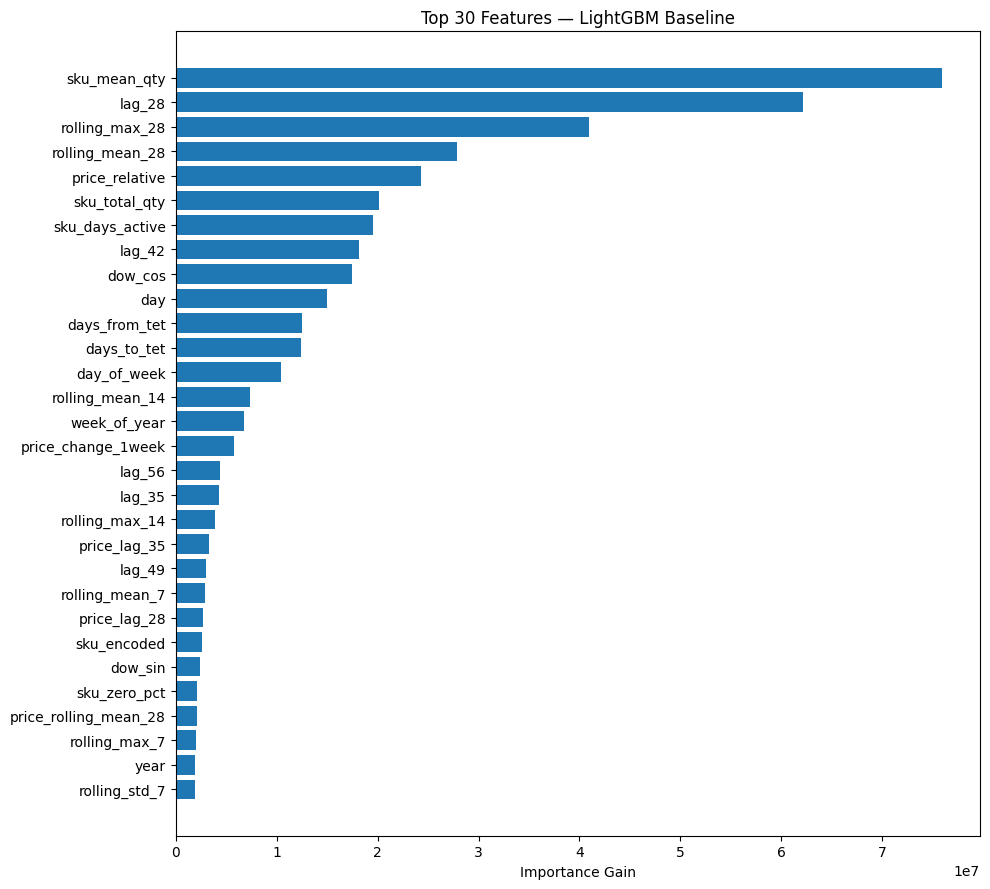

Saved figure: /content/drive/MyDrive/HBAAC_Redefinity_2026/03_Reports/Figures/feature_importance_lgb_baseline_v1.png


In [16]:
top_n = 30
plot_df = importance_df.head(top_n).sort_values('importance_gain')

plt.figure(figsize=(10, 9))
plt.barh(plot_df['feature'], plot_df['importance_gain'])
plt.title('Top 30 Features — LightGBM Baseline')
plt.xlabel('Importance Gain')
plt.tight_layout()

fig_path = f'{FIGURES_PATH}/feature_importance_lgb_baseline_v1.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved figure:', fig_path)

In [18]:
import os

MODEL_PATH = "/content/drive/MyDrive/HBAAC_Redefinity_2026/02_Models"
DATA_PROCESSED = "/content/drive/MyDrive/HBAAC_Redefinity_2026/01_Data/processed"
FIGURES_PATH = "/content/drive/MyDrive/HBAAC_Redefinity_2026/03_Reports/Figures"

model_path = f"{MODEL_PATH}/lgb_baseline_v1.pkl"

print("Model exists:", os.path.exists(model_path))
print("Model path:", model_path)

Model exists: True
Model path: /content/drive/MyDrive/HBAAC_Redefinity_2026/02_Models/lgb_baseline_v1.pkl


In [19]:
files_to_check = [
    f"{DATA_PROCESSED}/validation_predictions_lgb_baseline_v1.csv",
    f"{DATA_PROCESSED}/feature_importance_lgb_baseline_v1.csv",
    f"{MODEL_PATH}/lgb_baseline_v1_metrics.json",
    f"{FIGURES_PATH}/feature_importance_lgb_baseline_v1.png",
]

for path in files_to_check:
    print(path, "exists:", os.path.exists(path))

/content/drive/MyDrive/HBAAC_Redefinity_2026/01_Data/processed/validation_predictions_lgb_baseline_v1.csv exists: True
/content/drive/MyDrive/HBAAC_Redefinity_2026/01_Data/processed/feature_importance_lgb_baseline_v1.csv exists: True
/content/drive/MyDrive/HBAAC_Redefinity_2026/02_Models/lgb_baseline_v1_metrics.json exists: True
/content/drive/MyDrive/HBAAC_Redefinity_2026/03_Reports/Figures/feature_importance_lgb_baseline_v1.png exists: True


## 1️⃣3️⃣ Modeling Summary

Điền số sau khi chạy xong:

| Model | Local WRMSSE | Note |
|---|---:|---|
| Naive lag_28 | `wrmsse_naive` | baseline Linh dùng để compare |
| LightGBM baseline | `wrmsse_lgb` | phải thấp hơn naive |

Artifacts tạo ra:
- `02_Models/lgb_baseline_v1.pkl`
- `02_Models/lgb_baseline_v1_metrics.json`
- `01_Data/processed/validation_predictions_lgb_baseline_v1.csv`
- `01_Data/processed/feature_importance_lgb_baseline_v1.csv`
- `03_Reports/Figures/feature_importance_lgb_baseline_v1.png`

Next: nếu baseline ổn, sang `04_Final.ipynb` generate submission v2 hoặc Day 3 chạy Optuna tuning.
